# Visualize Leakage

   config   roc_auc     auprc  seg_sensitivity  seg_specificity    seg_f1  \
0     A10  0.964422  0.665816         0.857192         0.959745  0.494513   
1      A5  0.958107  0.636490         0.865991         0.952452  0.458835   
2     B10  0.963109  0.677345         0.788987         0.969327  0.527292   
3      B5  0.958237  0.630607         0.882430         0.947188  0.430980   
4     C10  0.955648  0.578854         0.868827         0.918438  0.345806   
5      C5  0.944750  0.532292         0.866773         0.902769  0.310638   
6     D10  0.930609  0.486029         0.840269         0.876848  0.286284   
7      D5  0.921614  0.435083         0.821342         0.880685  0.294912   
8     E10  0.974590  0.801845         0.747792         0.993110  0.709257   
9      E5  0.966783  0.763899         0.733398         0.990569  0.668345   
10    F10  0.973687  0.815727         0.630541         0.996513  0.666902   
11     F5  0.967337  0.748324         0.780992         0.986012  0.650124   

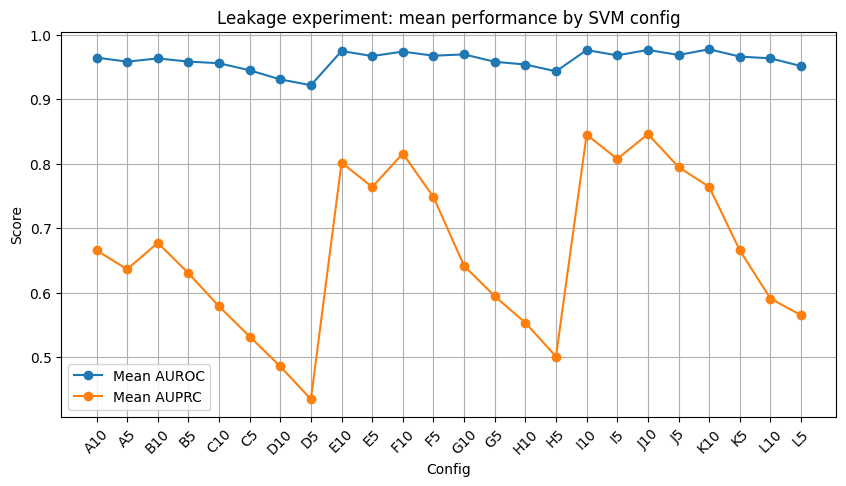

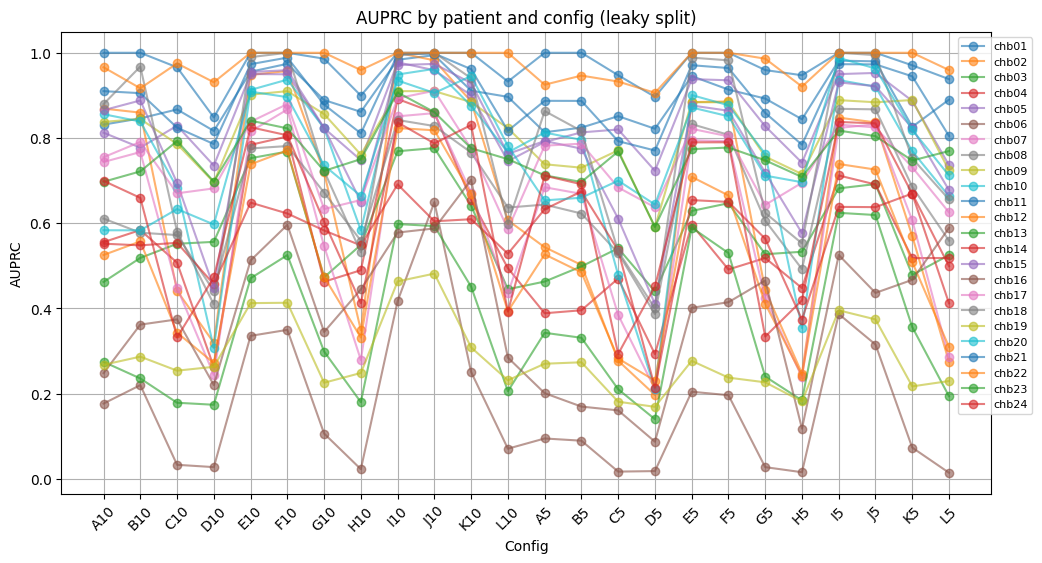

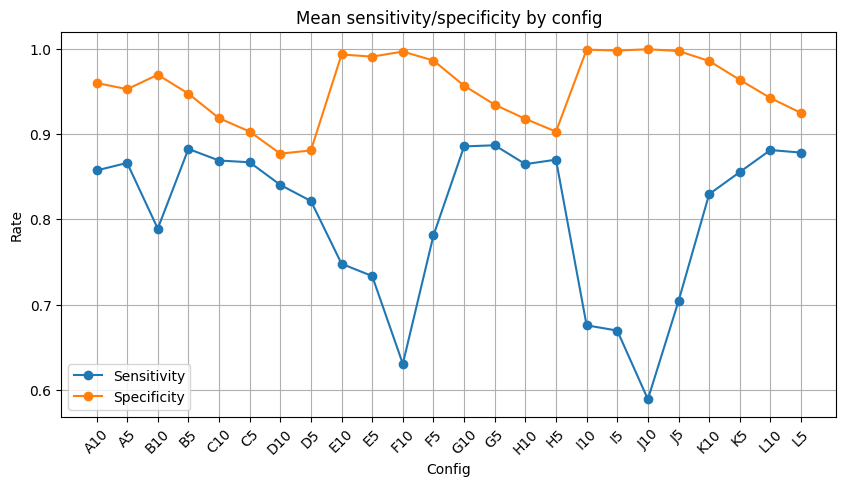

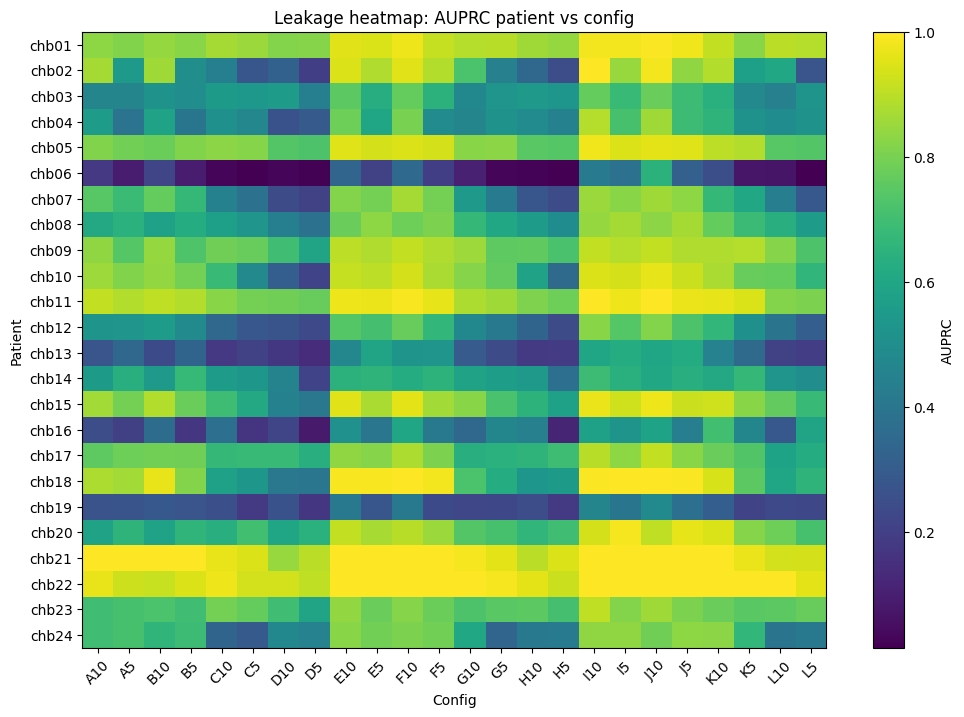

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("../RESULTS/RESULTS_LEAKY.csv")


# =====================================================
# 1. Mean performance across ALL patients by config
# =====================================================

config_summary = (
    df.groupby("config")
    [
        [
            "roc_auc",
            "auprc",
            "seg_sensitivity",
            "seg_specificity",
            "seg_f1",
            "fp",
            "fn"
        ]
    ]
    .mean()
    .reset_index()
)


print(config_summary)



# =====================================================
# 2. Compare AUROC and AUPRC by config
# =====================================================

plt.figure(figsize=(10,5))

plt.plot(
    config_summary["config"],
    config_summary["roc_auc"],
    marker="o",
    label="Mean AUROC"
)

plt.plot(
    config_summary["config"],
    config_summary["auprc"],
    marker="o",
    label="Mean AUPRC"
)

plt.xlabel("Config")
plt.ylabel("Score")
plt.title("Leakage experiment: mean performance by SVM config")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()



# =====================================================
# 3. AUPRC for every patient (shows leakage consistency)
# =====================================================

plt.figure(figsize=(12,6))


for patient in df["patient"].unique():

    d = df[df["patient"] == patient]

    plt.plot(
        d["config"],
        d["auprc"],
        marker="o",
        alpha=0.6,
        label=patient
    )


plt.xlabel("Config")
plt.ylabel("AUPRC")
plt.title("AUPRC by patient and config (leaky split)")
plt.xticks(rotation=45)
plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    fontsize=8
)

plt.show()



# =====================================================
# 4. Sensitivity vs Specificity per config
# =====================================================

plt.figure(figsize=(10,5))


plt.plot(
    config_summary["config"],
    config_summary["seg_sensitivity"],
    marker="o",
    label="Sensitivity"
)

plt.plot(
    config_summary["config"],
    config_summary["seg_specificity"],
    marker="o",
    label="Specificity"
)


plt.xlabel("Config")
plt.ylabel("Rate")
plt.title("Mean sensitivity/specificity by config")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()



# =====================================================
# 5. Heatmap: patient x config AUPRC
# =====================================================

import numpy as np


heat = df.pivot(
    index="patient",
    columns="config",
    values="auprc"
)


plt.figure(figsize=(12,8))


plt.imshow(
    heat.values,
    aspect="auto"
)


plt.colorbar(
    label="AUPRC"
)


plt.xticks(
    range(len(heat.columns)),
    heat.columns,
    rotation=45
)

plt.yticks(
    range(len(heat.index)),
    heat.index
)


plt.title("Leakage heatmap: AUPRC patient vs config")

plt.xlabel("Config")
plt.ylabel("Patient")

plt.show()

   config   roc_auc     auprc  seg_accuracy  seg_sensitivity  seg_specificity  \
0     A10  0.964422  0.665816      0.958088         0.857192         0.959745   
1      A5  0.958107  0.636490      0.951016         0.865991         0.952452   
2     B10  0.963109  0.677345      0.966697         0.788987         0.969327   
3      B5  0.958237  0.630607      0.945985         0.882430         0.947188   
4     C10  0.955648  0.578854      0.917461         0.868827         0.918438   
5      C5  0.944750  0.532292      0.902036         0.866773         0.902769   
6     D10  0.930609  0.486029      0.875747         0.840269         0.876848   
7      D5  0.921614  0.435083      0.878764         0.821342         0.880685   
8     E10  0.974590  0.801845      0.988624         0.747792         0.993110   
9      E5  0.966783  0.763899      0.986025         0.733398         0.990569   
10    F10  0.973687  0.815727      0.989770         0.630541         0.996513   
11     F5  0.967337  0.74832

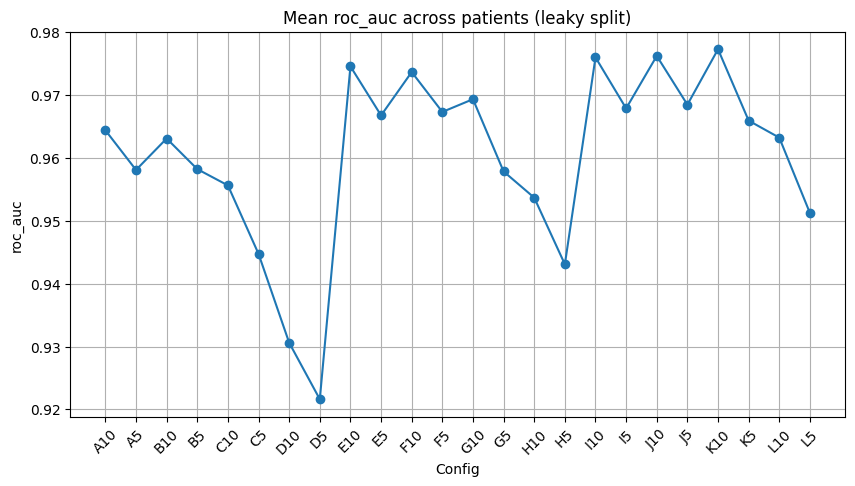

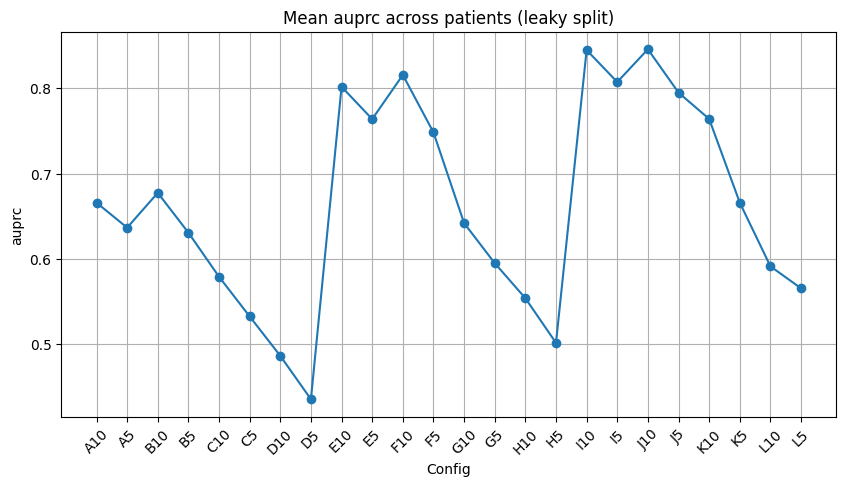

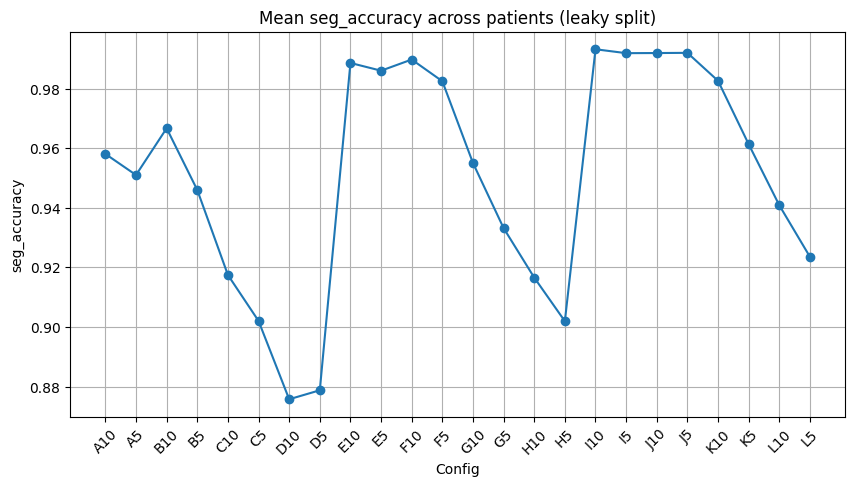

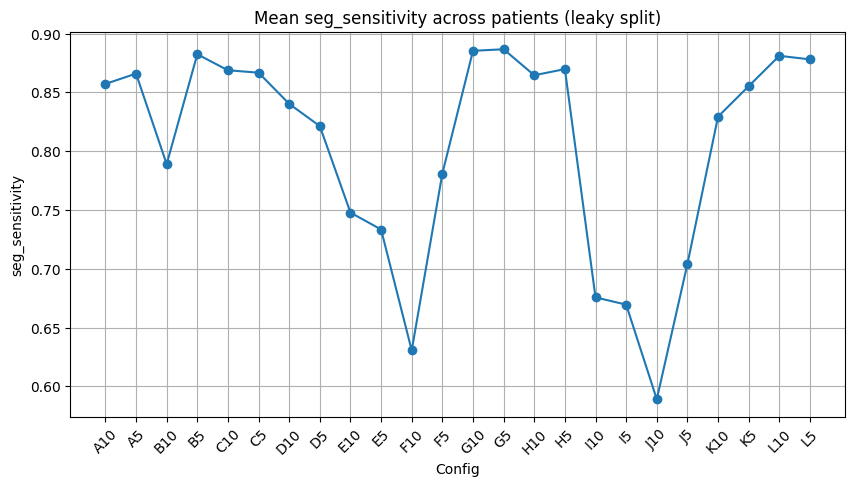

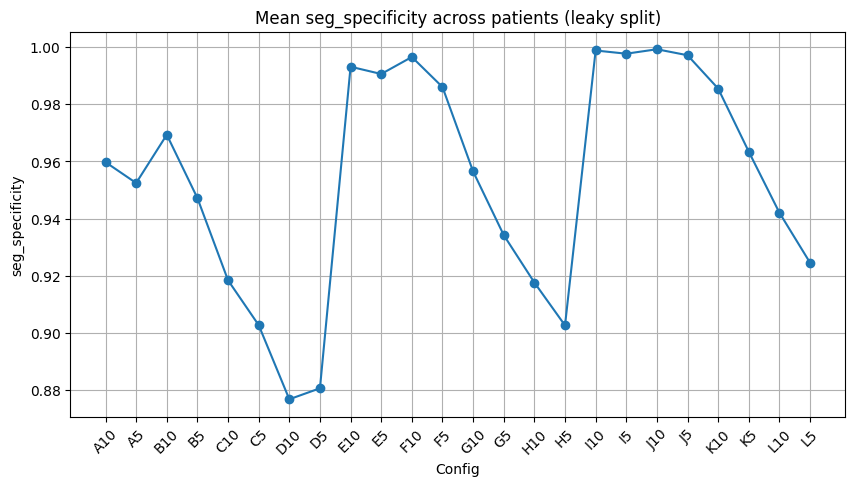

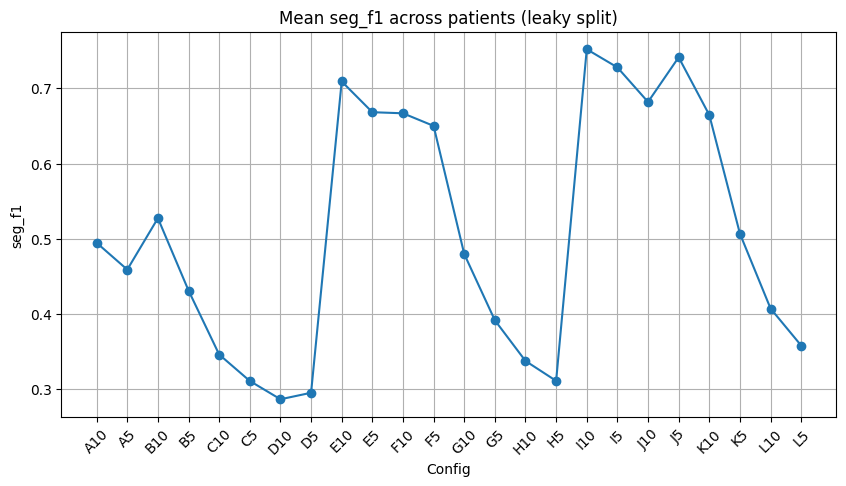

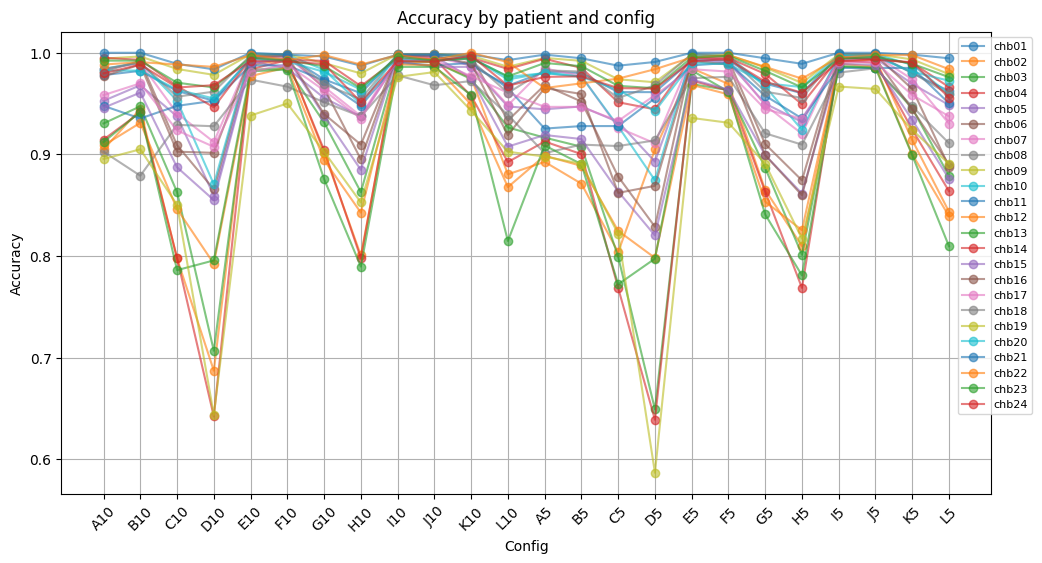

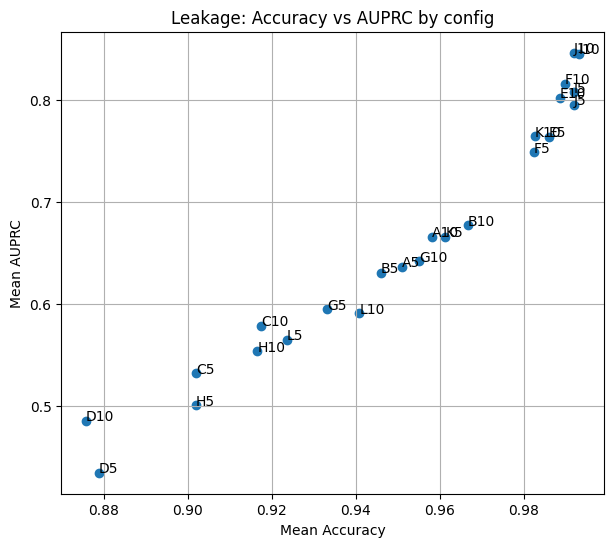

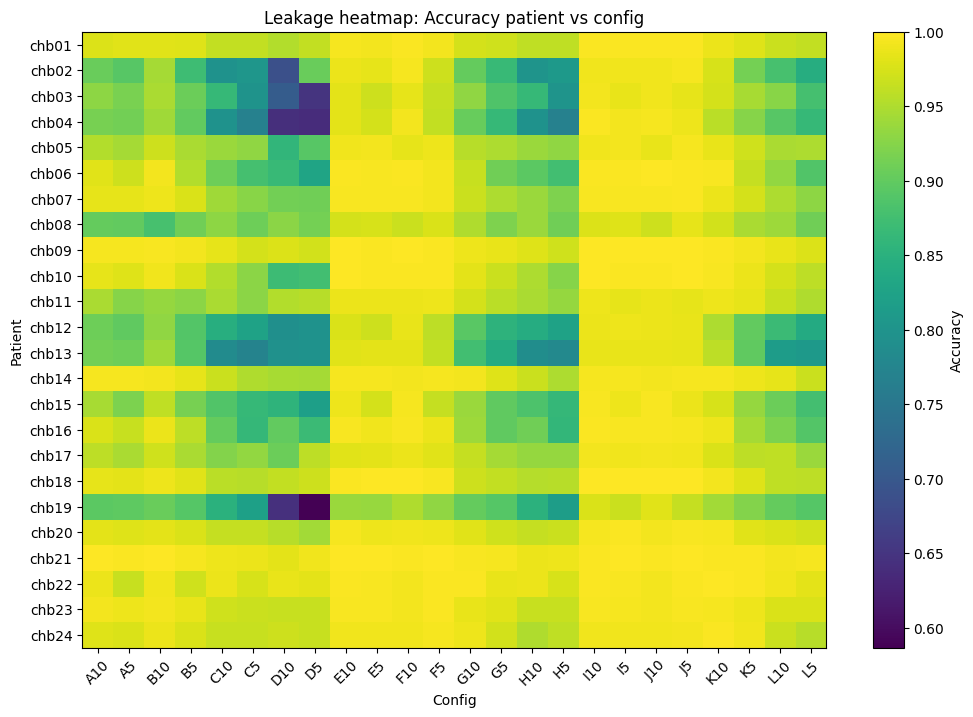

In [8]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("../RESULTS/RESULTS_LEAKY.csv")


# =====================================================
# 1. Mean metrics across ALL patients by config
# =====================================================

config_summary = (
    df.groupby("config")
    [
        [
            "roc_auc",
            "auprc",
            "seg_accuracy",
            "seg_sensitivity",
            "seg_specificity",
            "seg_f1",
            "fp",
            "fn"
        ]
    ]
    .mean()
    .reset_index()
)


print(config_summary)



# =====================================================
# 2. Compare all main metrics by config
# =====================================================

metrics = [
    "roc_auc",
    "auprc",
    "seg_accuracy",
    "seg_sensitivity",
    "seg_specificity",
    "seg_f1"
]


for metric in metrics:

    plt.figure(figsize=(10,5))

    plt.plot(
        config_summary["config"],
        config_summary[metric],
        marker="o"
    )

    plt.xlabel("Config")
    plt.ylabel(metric)
    plt.title(f"Mean {metric} across patients (leaky split)")
    plt.xticks(rotation=45)
    plt.grid(True)

    plt.show()



# =====================================================
# 3. Per-patient accuracy by config
# =====================================================

plt.figure(figsize=(12,6))


for patient in df["patient"].unique():

    d = df[df["patient"] == patient]

    plt.plot(
        d["config"],
        d["seg_accuracy"],
        marker="o",
        alpha=0.6,
        label=patient
    )


plt.xlabel("Config")
plt.ylabel("Accuracy")
plt.title("Accuracy by patient and config")
plt.xticks(rotation=45)
plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.05,1),
    fontsize=8
)

plt.show()



# =====================================================
# 4. Accuracy vs AUPRC tradeoff
# =====================================================

plt.figure(figsize=(7,6))


plt.scatter(
    config_summary["seg_accuracy"],
    config_summary["auprc"]
)


for i,row in config_summary.iterrows():

    plt.text(
        row["seg_accuracy"],
        row["auprc"],
        row["config"]
    )


plt.xlabel("Mean Accuracy")
plt.ylabel("Mean AUPRC")

plt.title(
    "Leakage: Accuracy vs AUPRC by config"
)

plt.grid(True)

plt.show()



# =====================================================
# 5. Heatmap accuracy patient x config
# =====================================================

heat = df.pivot(
    index="patient",
    columns="config",
    values="seg_accuracy"
)


plt.figure(figsize=(12,8))


plt.imshow(
    heat.values,
    aspect="auto"
)


plt.colorbar(
    label="Accuracy"
)


plt.xticks(
    range(len(heat.columns)),
    heat.columns,
    rotation=45
)

plt.yticks(
    range(len(heat.index)),
    heat.index
)


plt.title(
    "Leakage heatmap: Accuracy patient vs config"
)

plt.xlabel("Config")
plt.ylabel("Patient")

plt.show()

   config  seg_accuracy  seg_specificity  seg_sensitivity
0     A10      0.958088         0.959745         0.857192
1      A5      0.951016         0.952452         0.865991
2     B10      0.966697         0.969327         0.788987
3      B5      0.945985         0.947188         0.882430
4     C10      0.917461         0.918438         0.868827
5      C5      0.902036         0.902769         0.866773
6     D10      0.875747         0.876848         0.840269
7      D5      0.878764         0.880685         0.821342
8     E10      0.988624         0.993110         0.747792
9      E5      0.986025         0.990569         0.733398
10    F10      0.989770         0.996513         0.630541
11     F5      0.982489         0.986012         0.780992
12    G10      0.955049         0.956495         0.885371
13     G5      0.933199         0.934239         0.886692
14    H10      0.916584         0.917660         0.864580
15     H5      0.901947         0.902671         0.869814
16    I10     

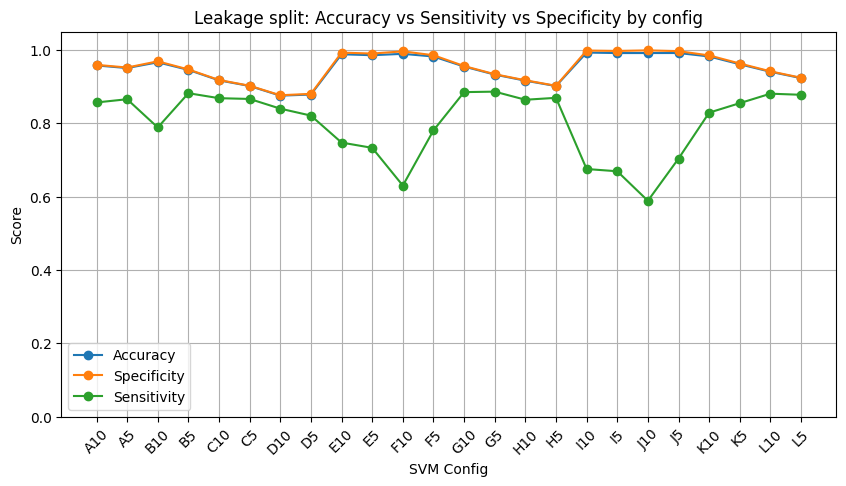

In [9]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("../RESULTS/RESULTS_LEAKY.csv")


# Mean across patients for each config
config_summary = (
    df.groupby("config")
    [
        [
            "seg_accuracy",
            "seg_specificity",
            "seg_sensitivity"
        ]
    ]
    .mean()
    .reset_index()
)


print(config_summary)



# =====================================================
# Accuracy vs Sensitivity vs Specificity
# =====================================================

plt.figure(figsize=(10,5))


plt.plot(
    config_summary["config"],
    config_summary["seg_accuracy"],
    marker="o",
    label="Accuracy"
)


plt.plot(
    config_summary["config"],
    config_summary["seg_specificity"],
    marker="o",
    label="Specificity"
)


plt.plot(
    config_summary["config"],
    config_summary["seg_sensitivity"],
    marker="o",
    label="Sensitivity"
)


plt.xlabel("SVM Config")
plt.ylabel("Score")
plt.title(
    "Leakage split: Accuracy vs Sensitivity vs Specificity by config"
)

plt.xticks(rotation=45)

plt.ylim(0,1.05)

plt.grid(True)

plt.legend()

plt.show()

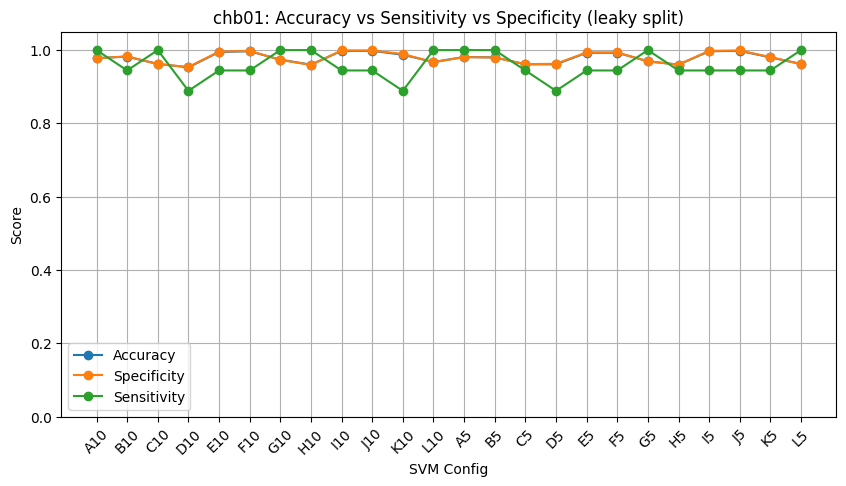

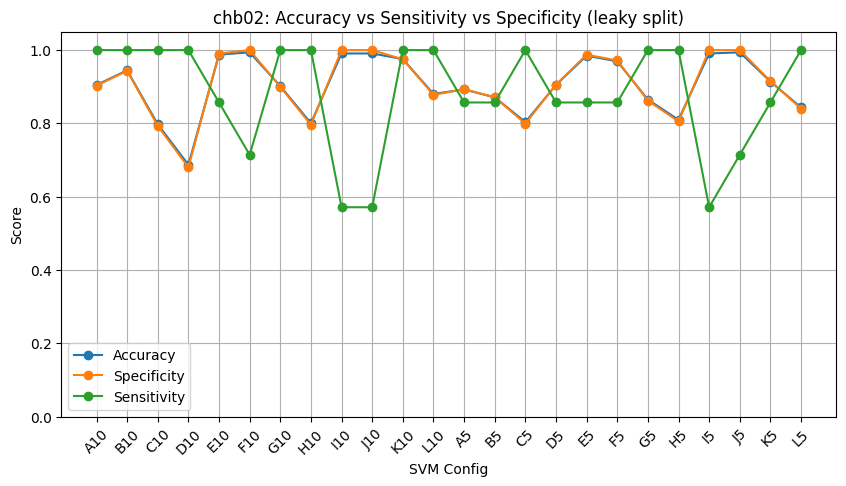

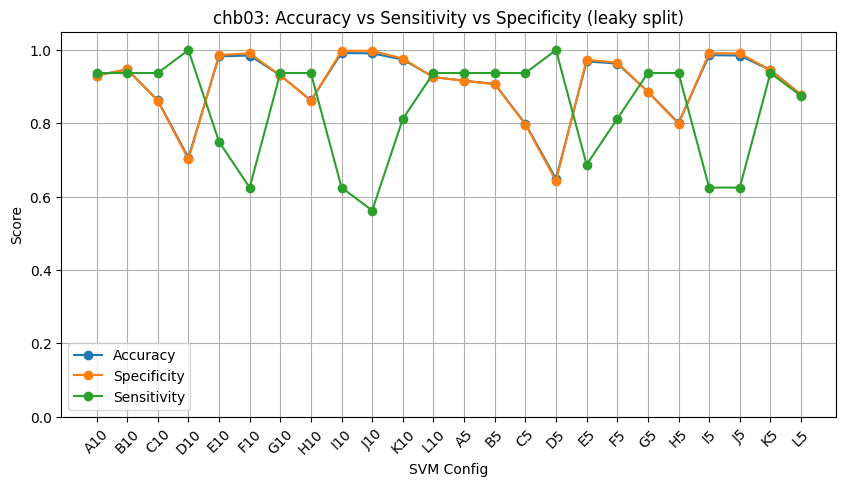

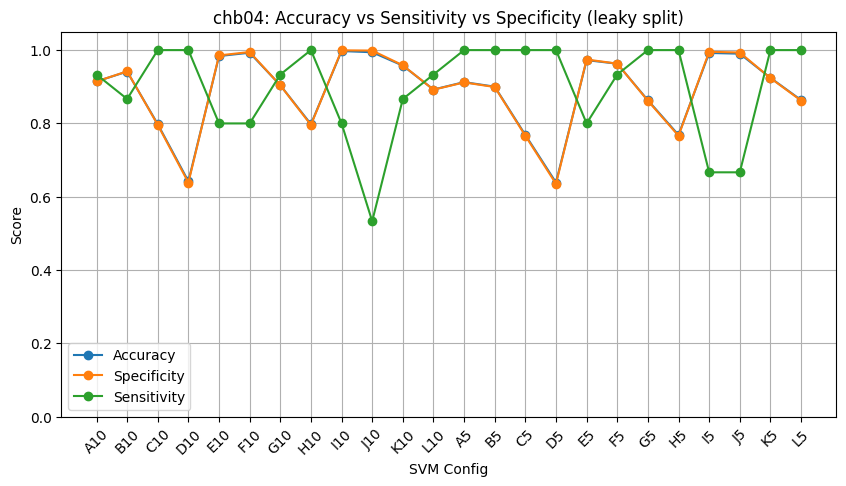

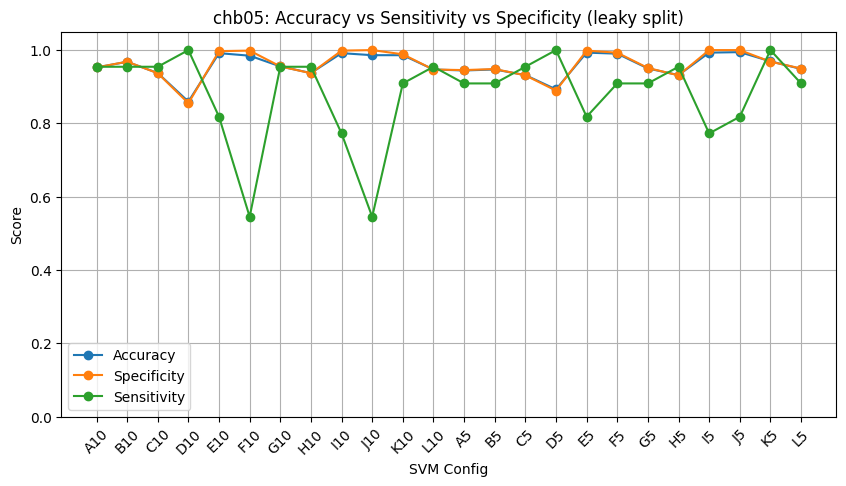

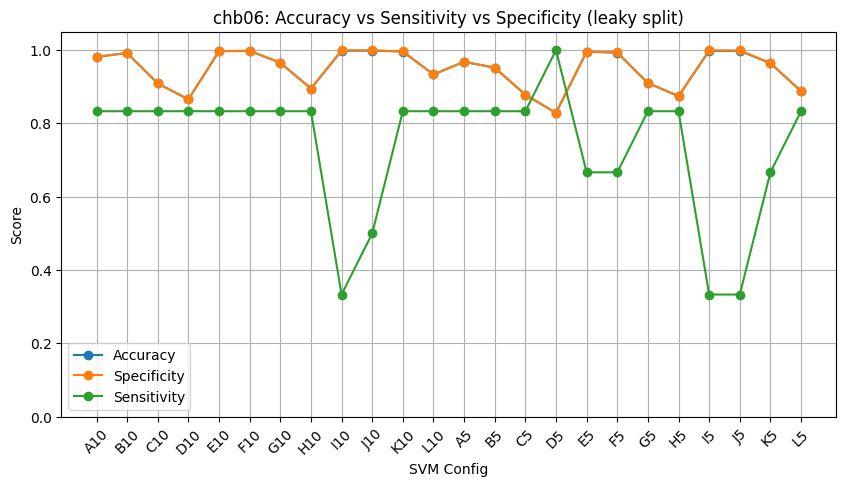

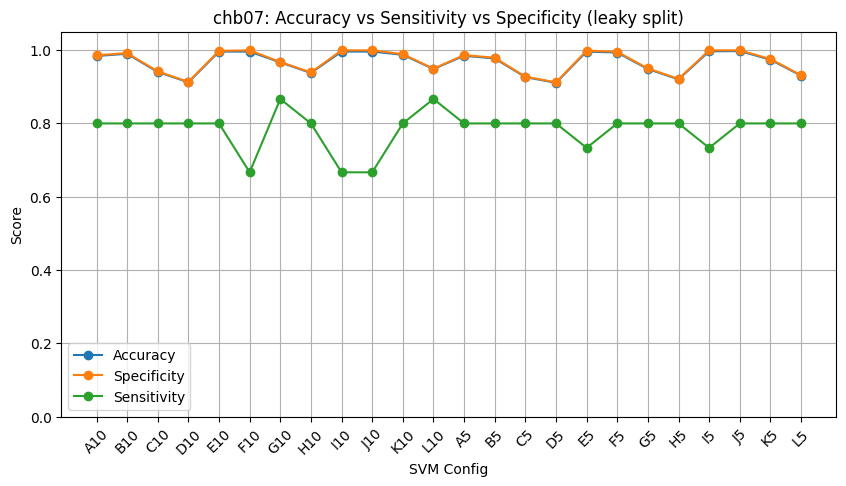

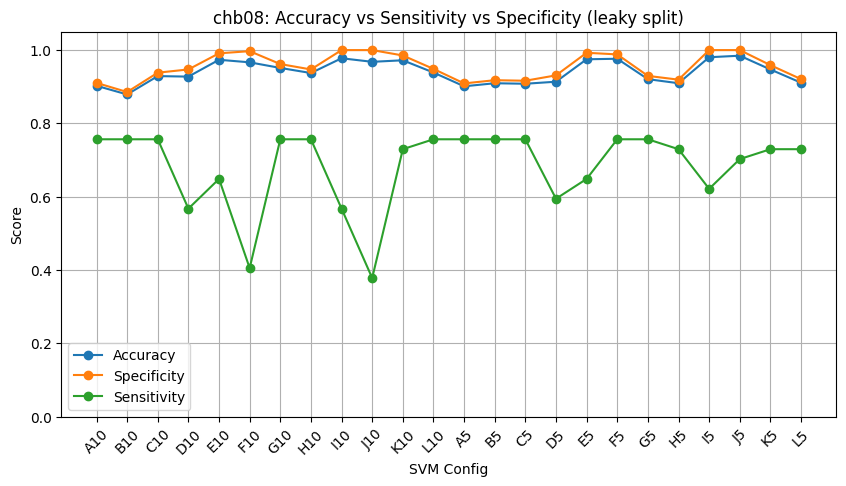

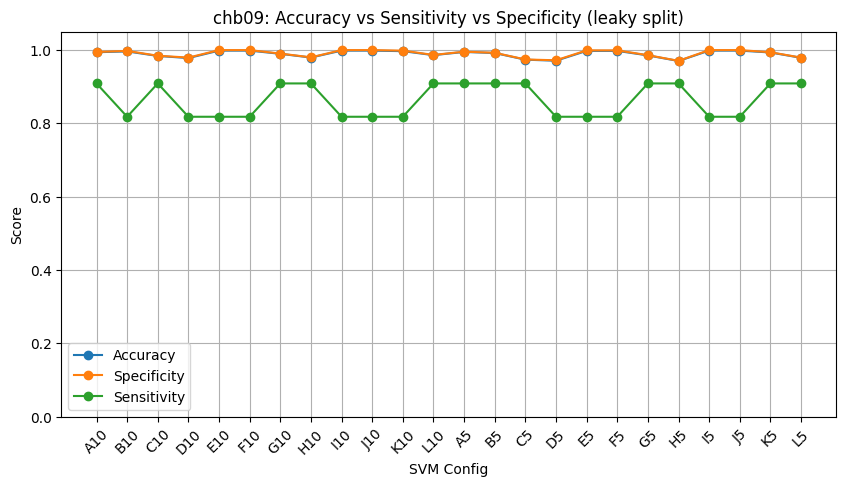

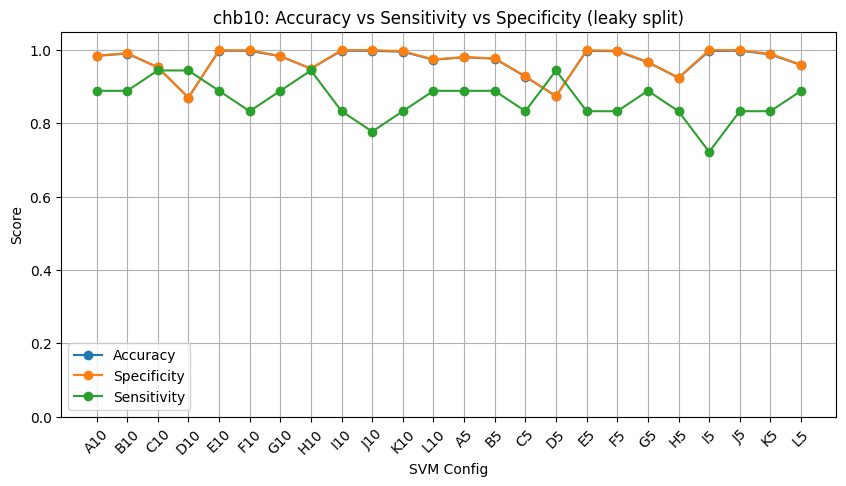

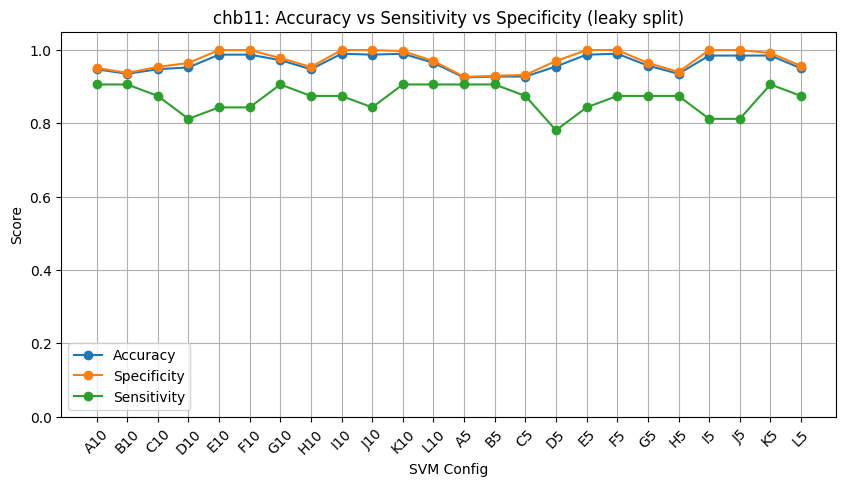

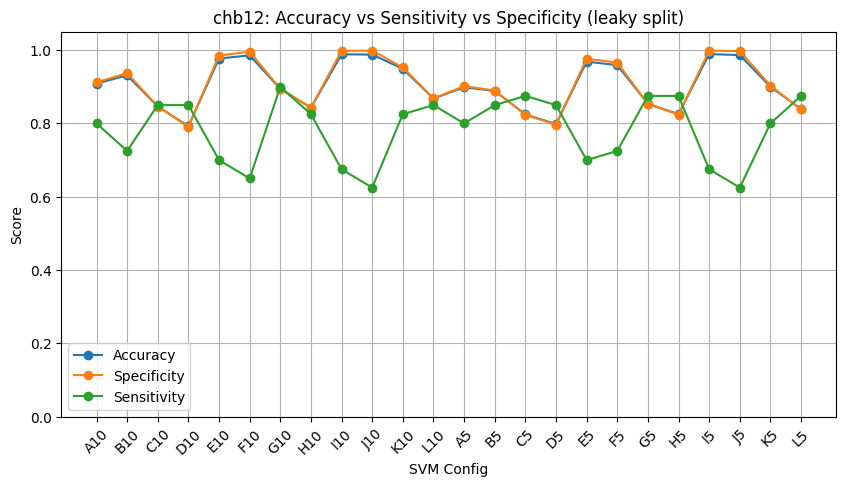

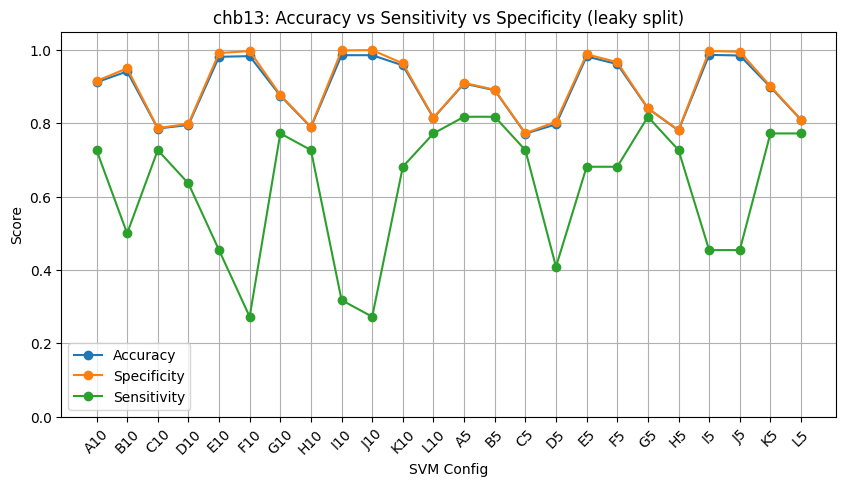

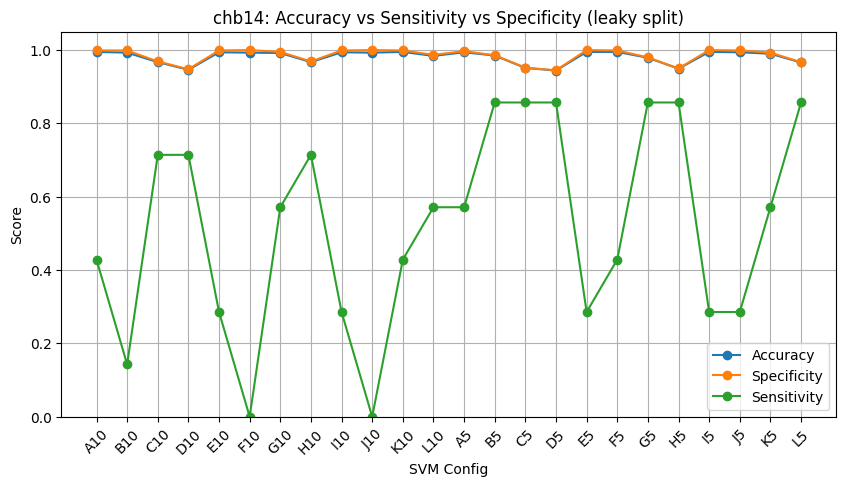

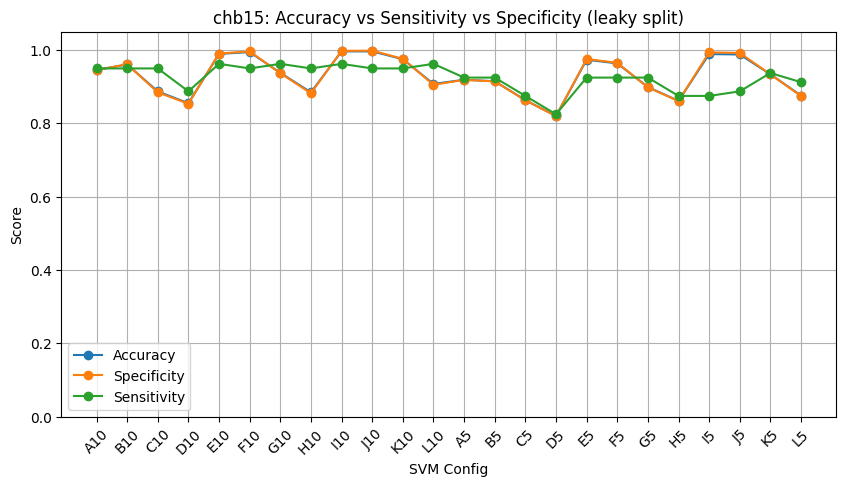

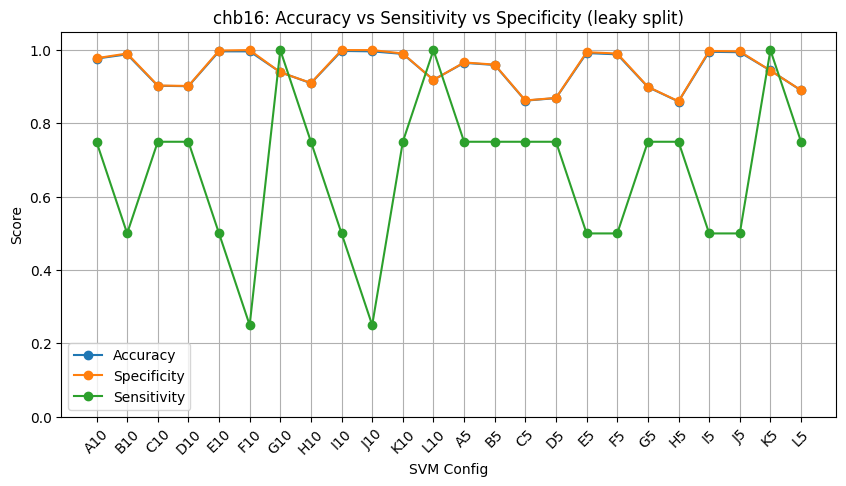

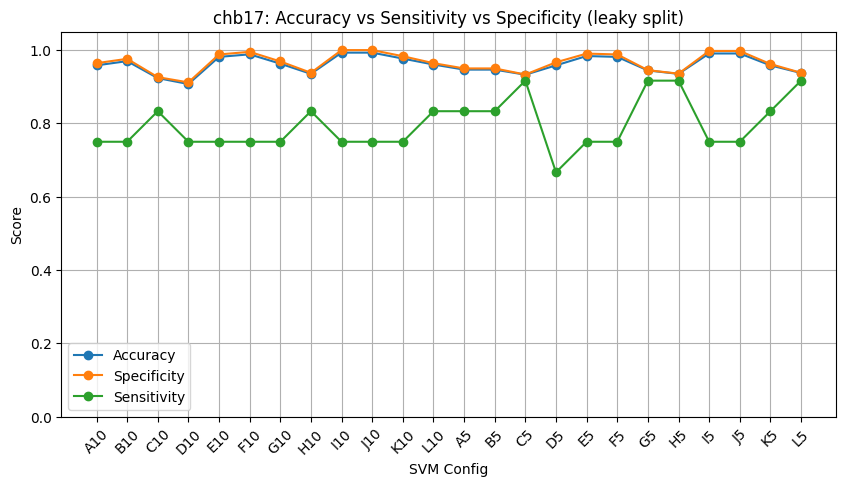

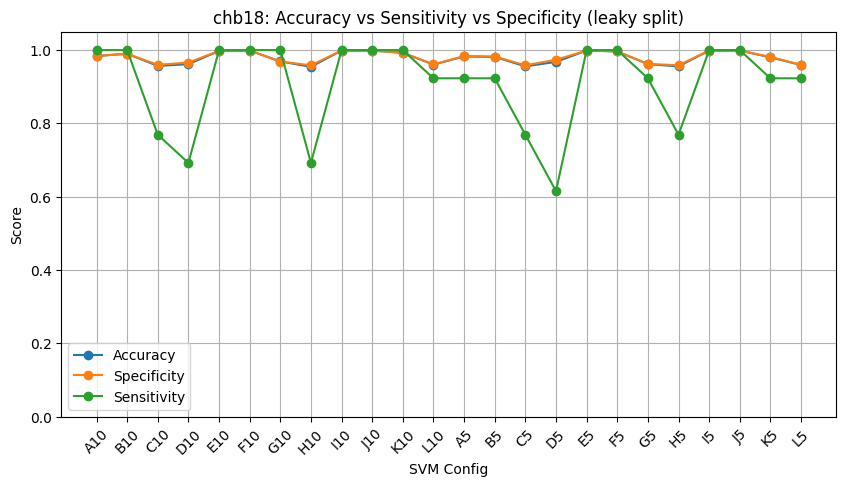

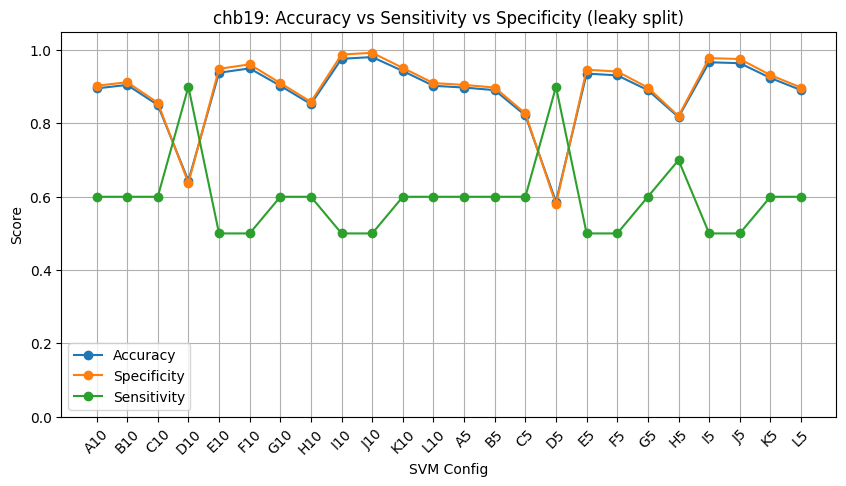

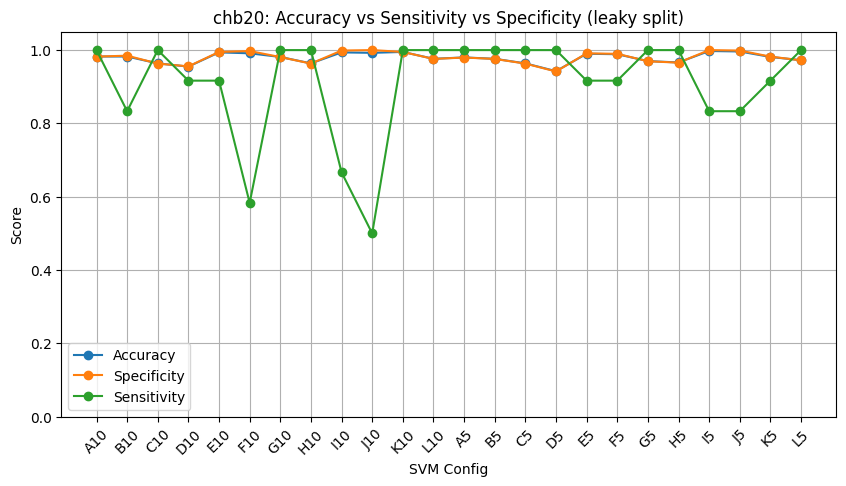

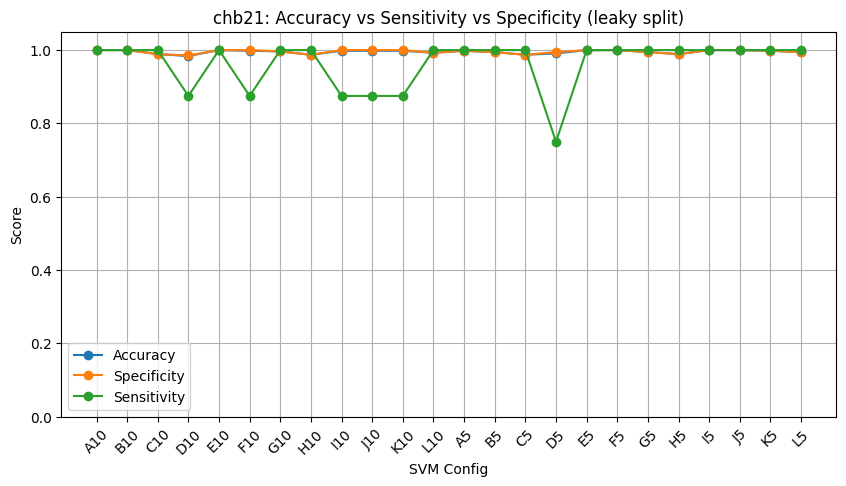

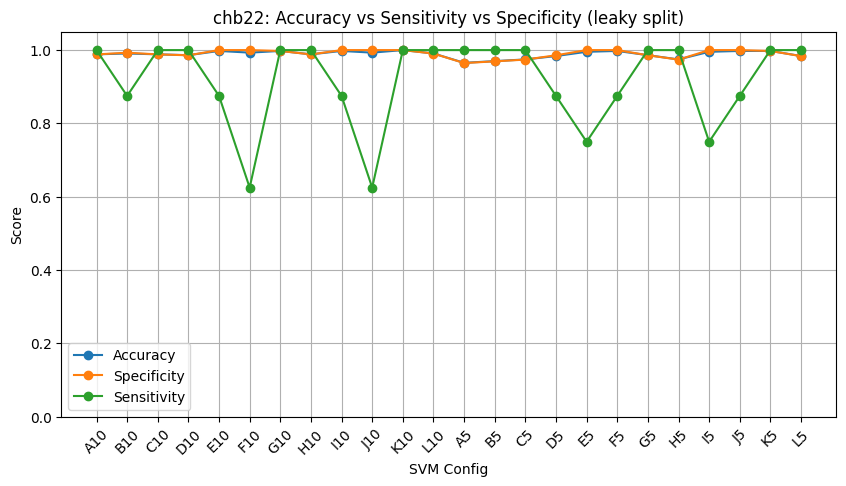

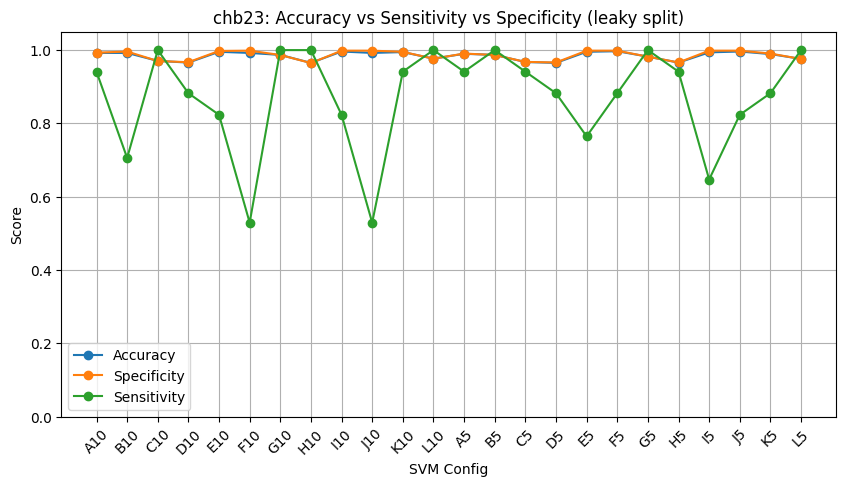

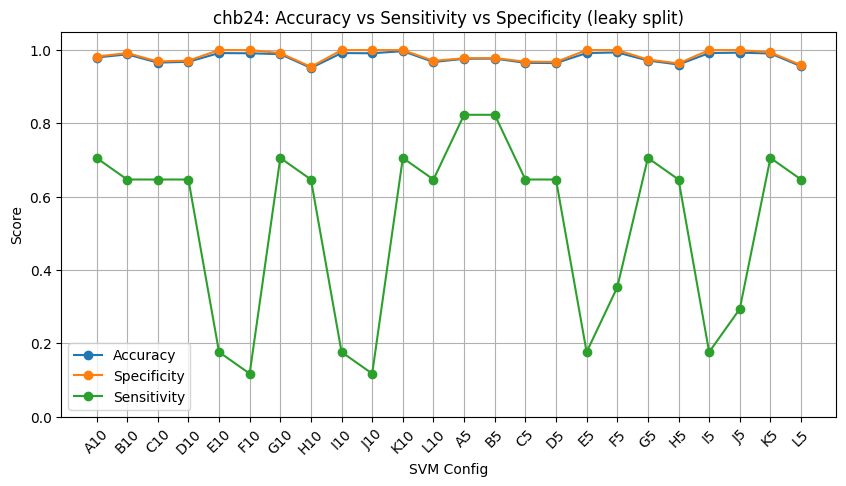

In [10]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("../RESULTS/RESULTS_LEAKY.csv")


# =====================================================
# Plot each patient separately
# =====================================================

for patient in df["patient"].unique():

    d = df[df["patient"] == patient]


    plt.figure(figsize=(10,5))


    plt.plot(
        d["config"],
        d["seg_accuracy"],
        marker="o",
        label="Accuracy"
    )


    plt.plot(
        d["config"],
        d["seg_specificity"],
        marker="o",
        label="Specificity"
    )


    plt.plot(
        d["config"],
        d["seg_sensitivity"],
        marker="o",
        label="Sensitivity"
    )


    plt.xlabel("SVM Config")
    plt.ylabel("Score")

    plt.title(
        f"{patient}: Accuracy vs Sensitivity vs Specificity (leaky split)"
    )


    plt.xticks(rotation=45)

    plt.ylim(0,1.05)

    plt.grid(True)

    plt.legend()

    plt.show()

In [11]:
patient_config_summary = (
    df.groupby(["config", "patient"])
    [
        [
            "seg_accuracy",
            "seg_specificity",
            "seg_sensitivity",
            "roc_auc",
            "auprc",
            "seg_f1"
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(["config", "patient"])
)


patient_config_summary

,config,patient,seg_accuracy,seg_specificity,seg_sensitivity,roc_auc,auprc,seg_f1
0,A10,chb01,0.978010,0.977588,1.000000,0.996443,0.831372,0.631579
1,A10,chb02,0.904908,0.902821,1.000000,0.992835,0.869048,0.311111
2,A10,chb03,0.930417,0.930303,0.937500,0.981629,0.462197,0.300000
3,A10,chb04,0.914602,0.914417,0.933333,0.981655,0.555589,0.176101
4,A10,chb05,0.952712,0.952654,0.954545,0.989827,0.812447,0.552632
...,...,...,...,...,...,...,...,...
571,L5,chb20,0.972500,0.972081,1.000000,0.994501,0.712114,0.521739
572,L5,chb21,0.994555,0.994475,1.000000,0.998849,0.938131,0.842105
573,L5,chb22,0.983796,0.983491,1.000000,0.999116,0.959375,0.695652
574,L5,chb23,0.975969,0.975648,1.000000,0.996488,0.769385,0.523077


In [12]:
import pandas as pd


df = pd.read_csv("../RESULTS/RESULTS_LEAKY.csv")


ab = df[df["config"].isin(["A10", "B10"])]


table = (
    ab.groupby(["config", "patient"])
    [
        [
            "seg_accuracy",
            "seg_specificity",
            "seg_sensitivity",
            "roc_auc",
            "auprc",
            "seg_f1"
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(["config","patient"])
)


table

,config,patient,seg_accuracy,seg_specificity,seg_sensitivity,roc_auc,auprc,seg_f1
0,A10,chb01,0.978010,0.977588,1.000000,0.996443,0.831372,0.631579
1,A10,chb02,0.904908,0.902821,1.000000,0.992835,0.869048,0.311111
2,A10,chb03,0.930417,0.930303,0.937500,0.981629,0.462197,0.300000
3,A10,chb04,0.914602,0.914417,0.933333,0.981655,0.555589,0.176101
4,A10,chb05,0.952712,0.952654,0.954545,0.989827,0.812447,0.552632
5,A10,chb06,0.981486,0.981725,0.833333,0.931649,0.176821,0.126582
6,A10,chb07,0.983914,0.985782,0.800000,0.956669,0.743711,0.500000
7,A10,chb08,0.902643,0.910557,0.756757,0.929896,0.610915,0.444444
8,A10,chb09,0.994199,0.994883,0.909091,0.910553,0.837749,0.714286
9,A10,chb10,0.984135,0.984992,0.888889,0.996054,0.855806,0.500000


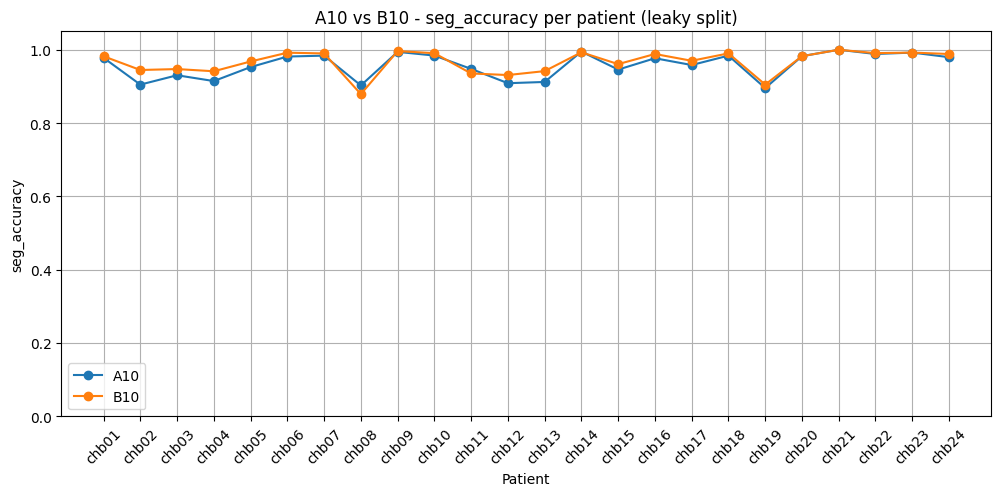

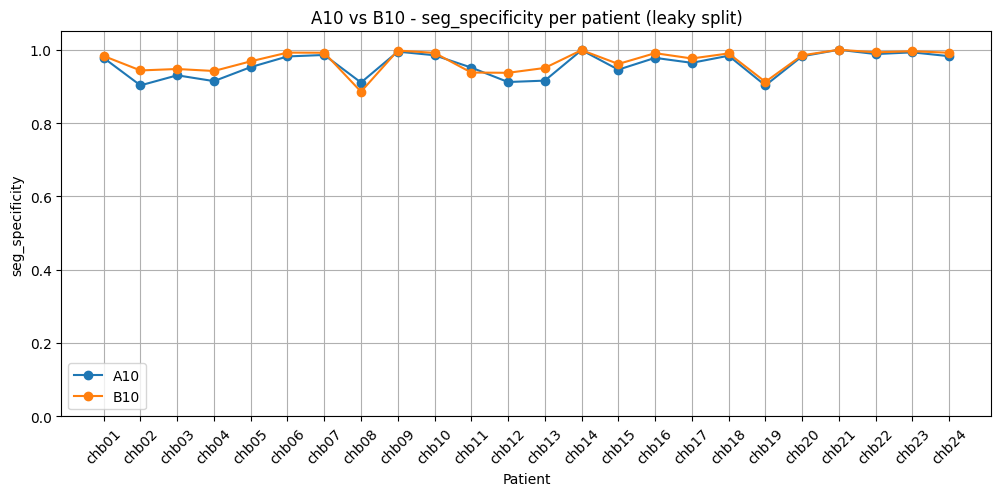

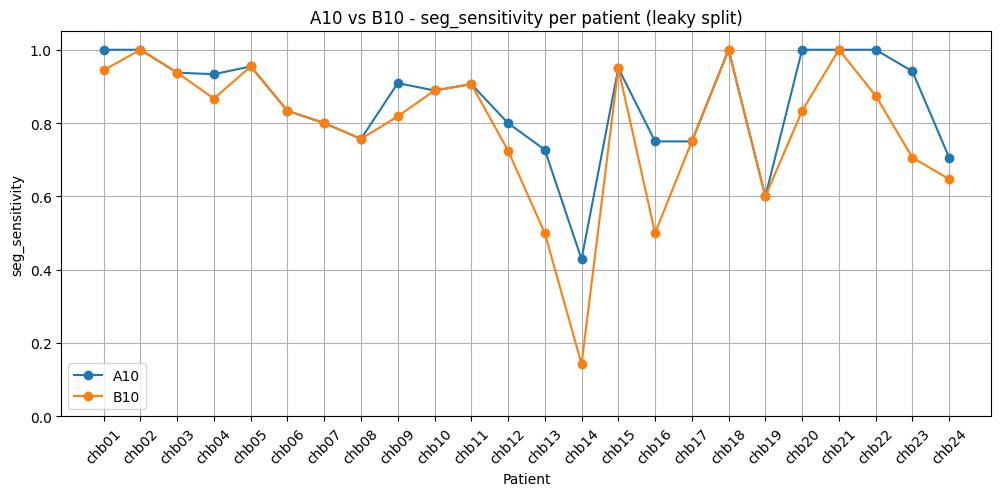

In [13]:
import matplotlib.pyplot as plt


metrics = [
    "seg_accuracy",
    "seg_specificity",
    "seg_sensitivity"
]


for metric in metrics:

    plt.figure(figsize=(12,5))


    for config in ["A10","B10"]:

        d = df[
            (df["config"] == config)
        ]

        plt.plot(
            d["patient"],
            d[metric],
            marker="o",
            label=config
        )


    plt.xlabel("Patient")
    plt.ylabel(metric)

    plt.title(
        f"A10 vs B10 - {metric} per patient (leaky split)"
    )

    plt.xticks(rotation=45)

    plt.ylim(0,1.05)

    plt.grid(True)

    plt.legend()

    plt.show()